In [1]:
import pandas as pd
df = pd.read_csv("esr_dataset_15k_final.csv")
print(df.isnull().sum().sum())
df.shape

0


(14999, 1030)

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy.signal import savgol_filter

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy.signal import savgol_filter

In [4]:
# Load dataset
data = pd.read_csv("esr_dataset_15k_final.csv", header=None)

# Split input and output
X = data.iloc[:, :-6].values
y = data.iloc[:, -6:].values

print("Dataset loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded
X shape: (15000, 1024)
y shape: (15000, 6)


In [5]:
print(np.min(X), np.max(X))
print(np.min(y), np.max(y))

-1.0 1.0
0.177348927885167 11.9997964131536


In [6]:
# Reduce size (faster + better training)
X = X[:, ::4]

print("After downsampling:", X.shape)

After downsampling: (15000, 256)


In [7]:
# Apply Savitzky-Golay filter
for i in range(X.shape[0]):
    X[i] = savgol_filter(X[i], window_length=15, polyorder=3)

print("Smoothing done")

Smoothing done


In [8]:
for i in range(X.shape[0]):
    X[i] = X[i] / np.max(np.abs(X[i]))

print("Normalization done")

Normalization done


In [9]:
# Add small noise
X += np.random.normal(0, 0.01, X.shape)

print("Augmentation done")

Augmentation done


In [10]:
# IMPORTANT: start from original X (before stacking)

# First derivative
X_diff1 = np.gradient(X, axis=1)

# Second derivative
X_diff2 = np.gradient(X_diff1, axis=1)

# Stack channels (ONLY ONCE)
X = np.stack([X, X_diff1, 2*X_diff2], axis=2)

print("Multi-channel shape:", X.shape)

Multi-channel shape: (15000, 256, 3)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (12000, 256, 3)
Test shape: (3000, 256, 3)


In [12]:
scaler = StandardScaler()

# reshape for scaler
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

X_train_2d = scaler.fit_transform(X_train_2d)
X_test_2d = scaler.transform(X_test_2d)

# reshape back
X_train = X_train_2d.reshape(X_train.shape)
X_test = X_test_2d.reshape(X_test.shape)

print("Scaling done")

Scaling done


In [13]:
y_train_scaled = y_train.copy()
y_test_scaled = y_test.copy()

# Physics-aware scaling
y_train_scaled[:,0:2] /= 2.0      # g
y_train_scaled[:,2:4] /= 0.5      # linewidth
y_train_scaled[:,4:6] /= 12.0     # hyperfine

y_test_scaled[:,0:2] /= 2.0
y_test_scaled[:,2:4] /= 0.5
y_test_scaled[:,4:6] /= 12.0

print("Output scaling done")

Output scaling done


In [14]:
print("Final X_train shape:", X_train.shape)
print("Final y_train shape:", y_train_scaled.shape)

Final X_train shape: (12000, 256, 3)
Final y_train shape: (12000, 6)


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [16]:
def residual_block(x, filters):

    shortcut = x

    x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Match dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

In [17]:
def attention_block(x):

    attn = layers.Dense(x.shape[-1], activation='softmax')(x)
    x = layers.Multiply()([x, attn])

    return x

In [18]:
inputs = tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2]))

x = layers.Conv1D(32, 5, padding='same', activation='relu')(inputs)

# Residual blocks
x = residual_block(x, 32)
x = layers.MaxPooling1D(2)(x)

x = residual_block(x, 64)
x = layers.MaxPooling1D(2)(x)

x = residual_block(x, 128)

# Attention
x = attention_block(x)

# Global pooling
x = layers.GlobalAveragePooling1D()(x)

# Dense layers
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(6)(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 32)   │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 32)   │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 32)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 32)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 128, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 64)   │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 128, 64)   │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 64)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 64, 64)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 64, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 177,862 (694.77 KB)

 Trainable params: 176,966 (691.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [19]:
def custom_loss(y_true, y_pred):

    weights = tf.constant([1.0,1.0,2.0,2.0,6.0,6.0])

    abs_error = tf.abs(y_true - y_pred)
    rel_error = abs_error / (tf.abs(y_true) + 1e-6)

    loss = weights * (0.5*abs_error + 0.5*rel_error)

    return tf.reduce_mean(loss)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=custom_loss,
    metrics=['mae']
)

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5)
]

In [22]:
history = model.fit(
    X_train,
    y_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.5591 - mae: 0.1709 - val_loss: 0.5355 - val_mae: 0.1440 - learning_rate: 5.0000e-04
Epoch 2/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.3172 - mae: 0.0768 - val_loss: 0.3004 - val_mae: 0.0584 - learning_rate: 5.0000e-04
Epoch 3/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2954 - mae: 0.0674 - val_loss: 0.3153 - val_mae: 0.0699 - learning_rate: 5.0000e-04
Epoch 4/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2864 - mae: 0.0633 - val_loss: 0.2769 - val_mae: 0.0531 - learning_rate: 5.0000e-04
Epoch 5/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2769 - mae: 0.0595 - val_loss: 0.2772 - val_mae: 0.0589 - learning_rate: 5.0000e-04
Epoch 6/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2714 - mae: 0.0570 - val_loss: 0.2523 - val_mae: 0.0465 - learning_rate: 5.0000e-04
Epoch 7/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.2641 - mae: 0.0536 - val_loss: 0.2572 - val_mae

In [23]:
pred_scaled = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [24]:
pred = pred_scaled.copy()

# Reverse scaling
pred[:,0:2] *= 2.0      # g
pred[:,2:4] *= 0.5      # linewidth
pred[:,4:6] *= 12.0     # hyperfine

y_true = y_test.copy()

In [27]:
pred_scaled = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

overall_mae = mean_absolute_error(y_true, pred)
overall_mse = mean_squared_error(y_true, pred)

print("OVERALL PERFORMANCE")
print("MAE:", round(overall_mae,4))
print("MSE:", round(overall_mse,4))

OVERALL PERFORMANCE
MAE: 0.3608
MSE: 0.6376


In [30]:
names = ["g1","g2","lw1","lw2","A1","A2"]

print("\nPARAMETER-WISE ERRORS\n")

for i, name in enumerate(names):

    mae = mean_absolute_error(y_true[:,i], pred[:,i])
    mse = mean_squared_error(y_true[:,i], pred[:,i])
    rmse = np.sqrt(mse)

    print(f"{name}:")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MSE  = {mse:.4f}\n")


PARAMETER-WISE ERRORS

g1:
  MAE  = 0.0040
  RMSE = 0.0051
  MSE  = 0.0000

g2:
  MAE  = 0.0046
  RMSE = 0.0058
  MSE  = 0.0000

lw1:
  MAE  = 0.0151
  RMSE = 0.0195
  MSE  = 0.0004

lw2:
  MAE  = 0.0152
  RMSE = 0.0199
  MSE  = 0.0004

A1:
  MAE  = 1.0413
  RMSE = 1.3449
  MSE  = 1.8086

A2:
  MAE  = 1.0848
  RMSE = 1.4200
  MSE  = 2.0164



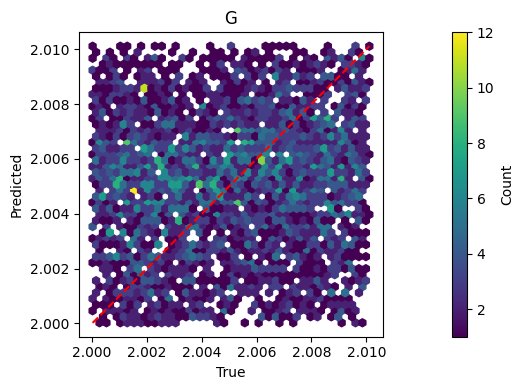

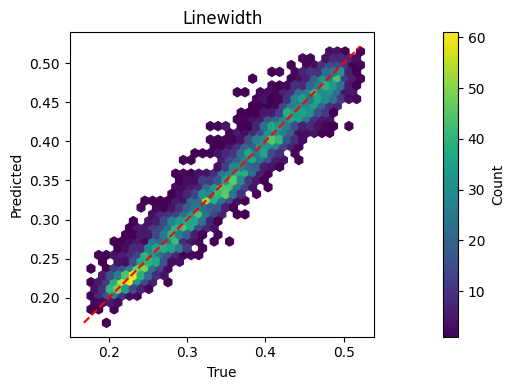

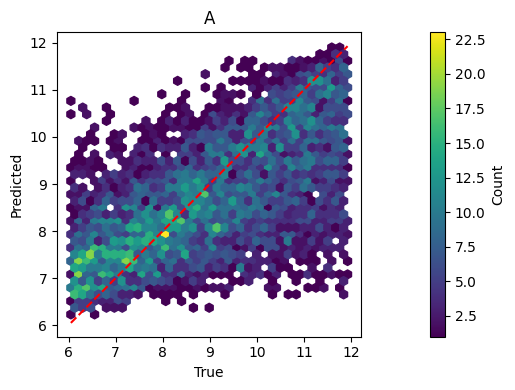

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------- 1) G PARITY PLOT -----------------------------
k = "G"
t = group_true[k]
p = group_pred[k]

# Remove outliers (1%–99%)
low, high = np.percentile(t, [1, 99])
mask = (t >= low) & (t <= high) & (p >= low) & (p <= high)
t_clean = t[mask]
p_clean = p[mask]

fig, ax = plt.subplots(figsize=(14, 4))  # very horizontal rectangle
hb = ax.hexbin(t_clean, p_clean, gridsize=40, cmap="viridis", mincnt=1)

# Minimal padding (5% of range)
data_min = min(t_clean.min(), p_clean.min())
data_max = max(t_clean.max(), p_clean.max())
padding = 0.05 * (data_max - data_min)

ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

# Ideal parity line
ax.plot([data_min, data_max], [data_min, data_max], "r--", lw=1.5)

ax.set_title("G")
ax.set_xlabel("True")
ax.set_ylabel("Predicted")
ax.set_aspect('equal', adjustable='box')

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count")

plt.tight_layout()
plt.show()


# ----------------------------- 2) Linewidth PARITY PLOT -----------------------------
k = "Linewidth"
t = group_true[k]
p = group_pred[k]

fig, ax = plt.subplots(figsize=(14, 4))  # very horizontal rectangle
hb = ax.hexbin(t, p, gridsize=35, cmap="viridis", mincnt=1)

# Minimal padding (5% of range)
data_min = min(t.min(), p.min())
data_max = max(t.max(), p.max())
padding = 0.05 * (data_max - data_min)

ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

# Ideal line
ax.plot([data_min, data_max], [data_min, data_max], "r--", lw=1.5)

ax.set_title("Linewidth")
ax.set_xlabel("True")
ax.set_ylabel("Predicted")
ax.set_aspect('equal', adjustable='box')

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count")

plt.tight_layout()
plt.show()


# ----------------------------- 3) A PARITY PLOT -----------------------------
k = "A"
t = group_true[k]
p = group_pred[k]

# Remove outliers (1%–99%)
low, high = np.percentile(t, [1, 99])
mask = (t >= low) & (t <= high) & (p >= low) & (p <= high)
t_clean = t[mask]
p_clean = p[mask]

fig, ax = plt.subplots(figsize=(14, 4))  # very horizontal rectangle
hb = ax.hexbin(t_clean, p_clean, gridsize=35, cmap="viridis", mincnt=1)

# Minimal padding (5% of range)
data_min = min(t_clean.min(), p_clean.min())
data_max = max(t_clean.max(), p_clean.max())
padding = 0.05 * (data_max - data_min)

ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

# Ideal line
ax.plot([data_min, data_max], [data_min, data_max], "r--", lw=1.5)

ax.set_title("A")
ax.set_xlabel("True")
ax.set_ylabel("Predicted")
ax.set_aspect('equal', adjustable='box')

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count")

plt.tight_layout()
plt.show()

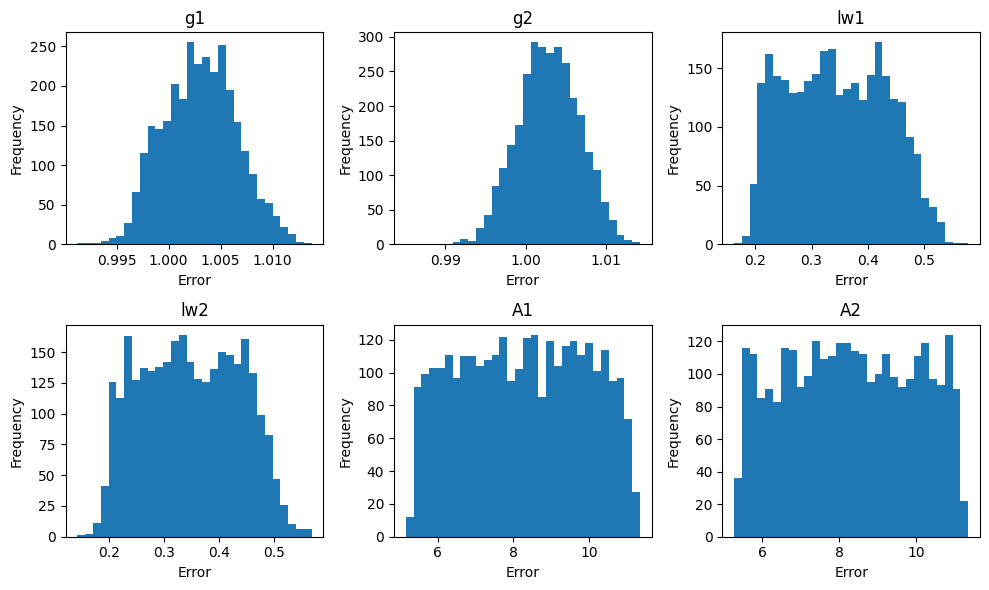

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Absolute error
errors = np.abs(y_test - predictions)

params = ['g1','g2','lw1','lw2','A1','A2']

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.hist(errors[:,i], bins=30)
    plt.title(params[i])
    plt.xlabel("Error")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

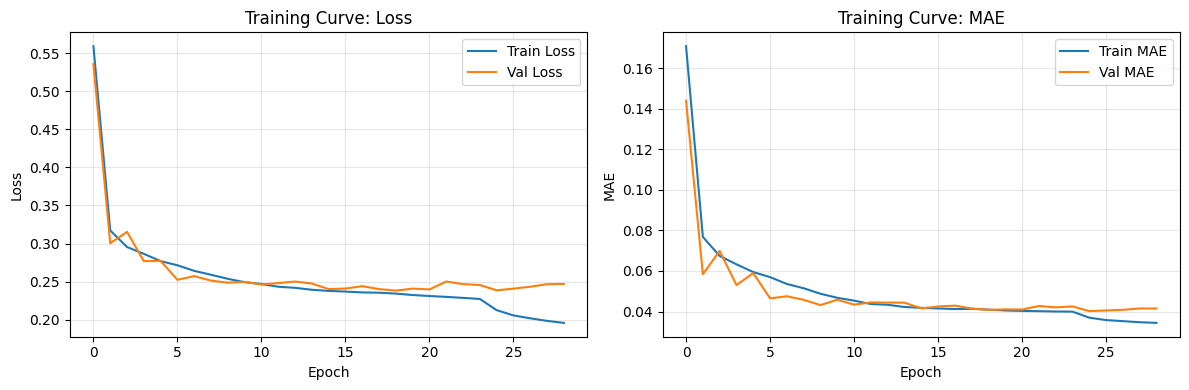

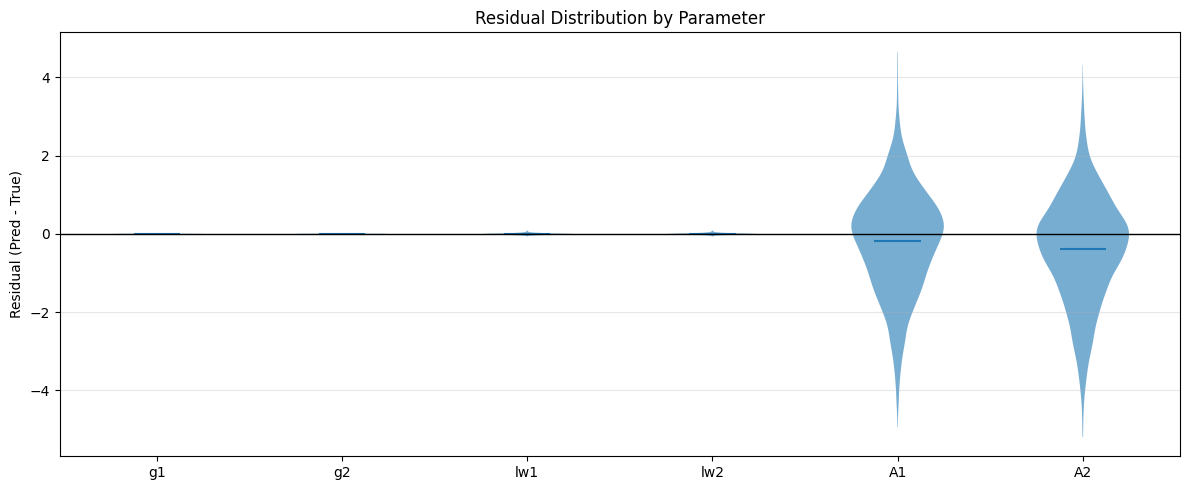

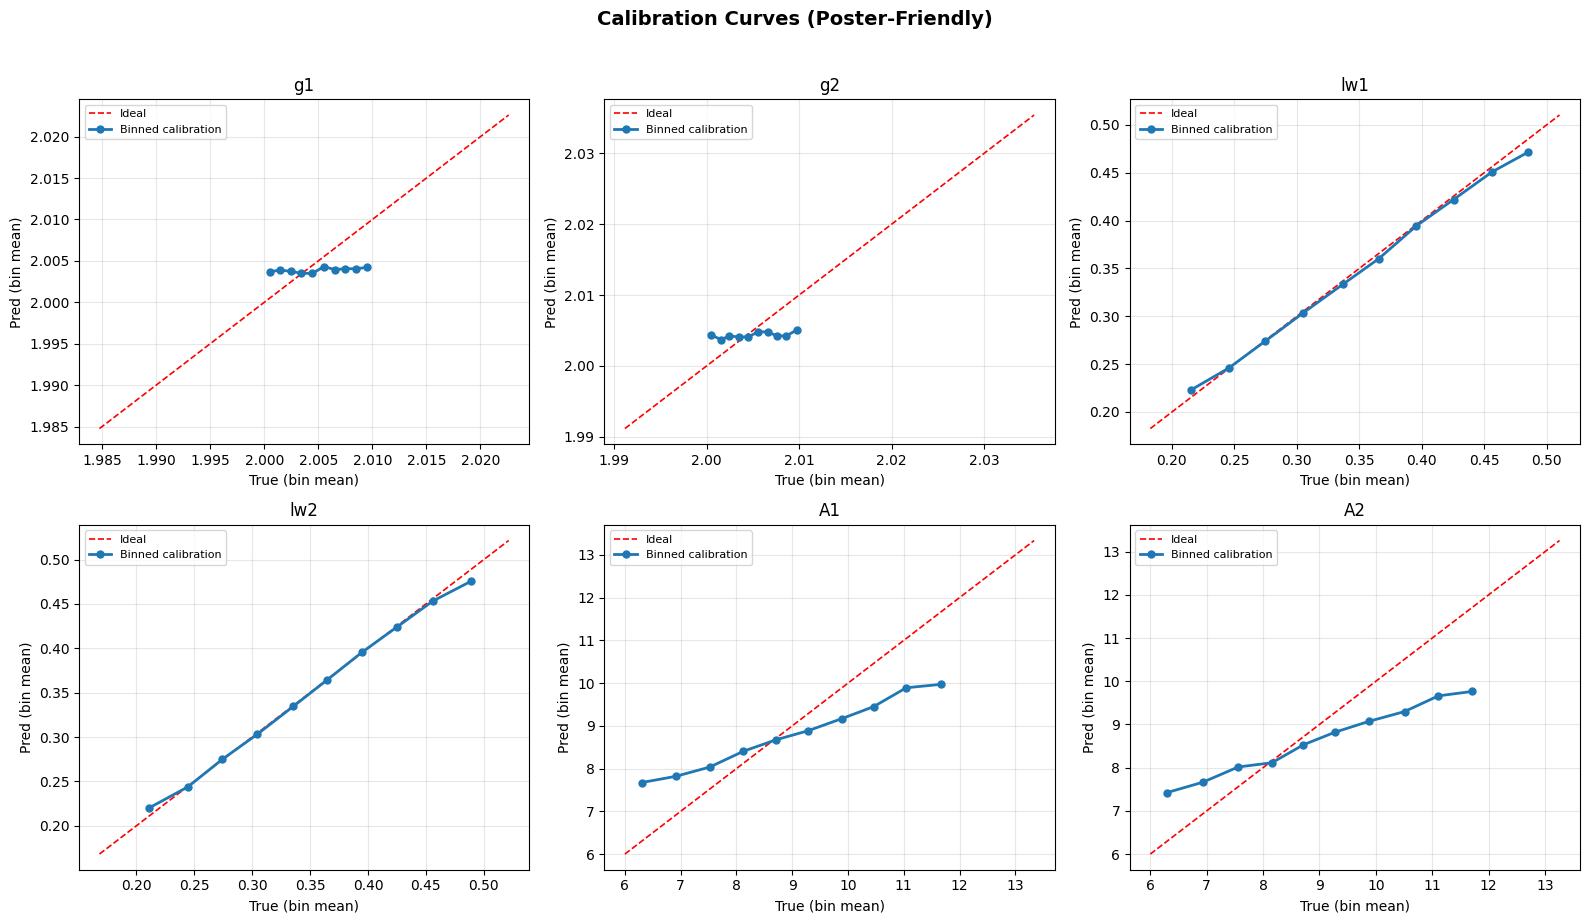

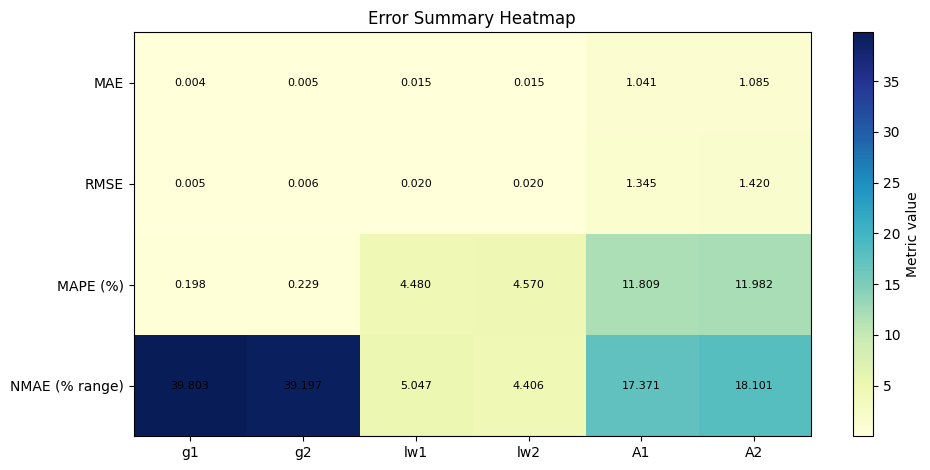

In [68]:
# Poster-ready additional evaluation plots

params = names if "names" in globals() else [f"p{i+1}" for i in range(y_true.shape[1])]

residuals = pred - y_true
abs_err = np.abs(residuals)

# -------------------- 1) Training curves --------------------
if "history" in globals() and hasattr(history, "history"):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if "loss" in h:
        axes[0].plot(h["loss"], label="Train Loss")
    if "val_loss" in h:
        axes[0].plot(h["val_loss"], label="Val Loss")
    axes[0].set_title("Training Curve: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    if "mae" in h:
        axes[1].plot(h["mae"], label="Train MAE")
    if "val_mae" in h:
        axes[1].plot(h["val_mae"], label="Val MAE")
    axes[1].set_title("Training Curve: MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# -------------------- 2) Residual distribution per parameter --------------------
fig, ax = plt.subplots(figsize=(12, 5))
vp = ax.violinplot([residuals[:, i] for i in range(len(params))], showmeans=True, showextrema=False)

for body in vp["bodies"]:
    body.set_alpha(0.6)

ax.axhline(0, color="black", lw=1)
ax.set_xticks(np.arange(1, len(params) + 1))
ax.set_xticklabels(params)
ax.set_ylabel("Residual (Pred - True)")
ax.set_title("Residual Distribution by Parameter")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------- 3) Calibration curves (binned True vs Pred) --------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for j, ax in enumerate(axes):
    t = y_true[:, j]
    p = pred[:, j]

    q = np.quantile(t, np.linspace(0, 1, 11))
    bins = np.digitize(t, q[1:-1], right=True)

    t_bin = np.array([t[bins == b].mean() for b in range(10) if np.any(bins == b)])
    p_bin = np.array([p[bins == b].mean() for b in range(10) if np.any(bins == b)])

    mn = min(t.min(), p.min())
    mx = max(t.max(), p.max())

    ax.plot([mn, mx], [mn, mx], "r--", lw=1.2, label="Ideal")
    ax.plot(t_bin, p_bin, "o-", lw=2, ms=5, label="Binned calibration")
    ax.set_title(params[j])
    ax.set_xlabel("True (bin mean)")
    ax.set_ylabel("Pred (bin mean)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Calibration Curves (Poster-Friendly)", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# -------------------- 4) Metric heatmap --------------------
mae = np.mean(abs_err, axis=0)
rmse = np.sqrt(np.mean(residuals**2, axis=0))
mape = 100 * np.mean(abs_err / (np.abs(y_true) + 1e-8), axis=0)
nmae = 100 * mae / (np.ptp(y_true, axis=0) + 1e-8)

metric_names = ["MAE", "RMSE", "MAPE (%)", "NMAE (% range)"]
metric_matrix = np.vstack([mae, rmse, mape, nmae])

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(metric_matrix, aspect="auto", cmap="YlGnBu")

ax.set_xticks(np.arange(len(params)))
ax.set_xticklabels(params)
ax.set_yticks(np.arange(len(metric_names)))
ax.set_yticklabels(metric_names)
ax.set_title("Error Summary Heatmap")

for r in range(metric_matrix.shape[0]):
    for c in range(metric_matrix.shape[1]):
        ax.text(c, r, f"{metric_matrix[r, c]:.3f}", ha="center", va="center", fontsize=8, color="black")

cb = plt.colorbar(im, ax=ax)
cb.set_label("Metric value")

plt.tight_layout()
plt.show()

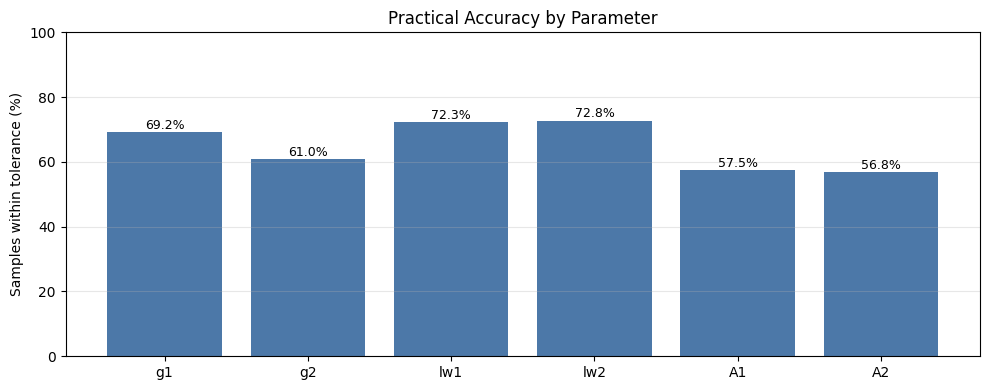

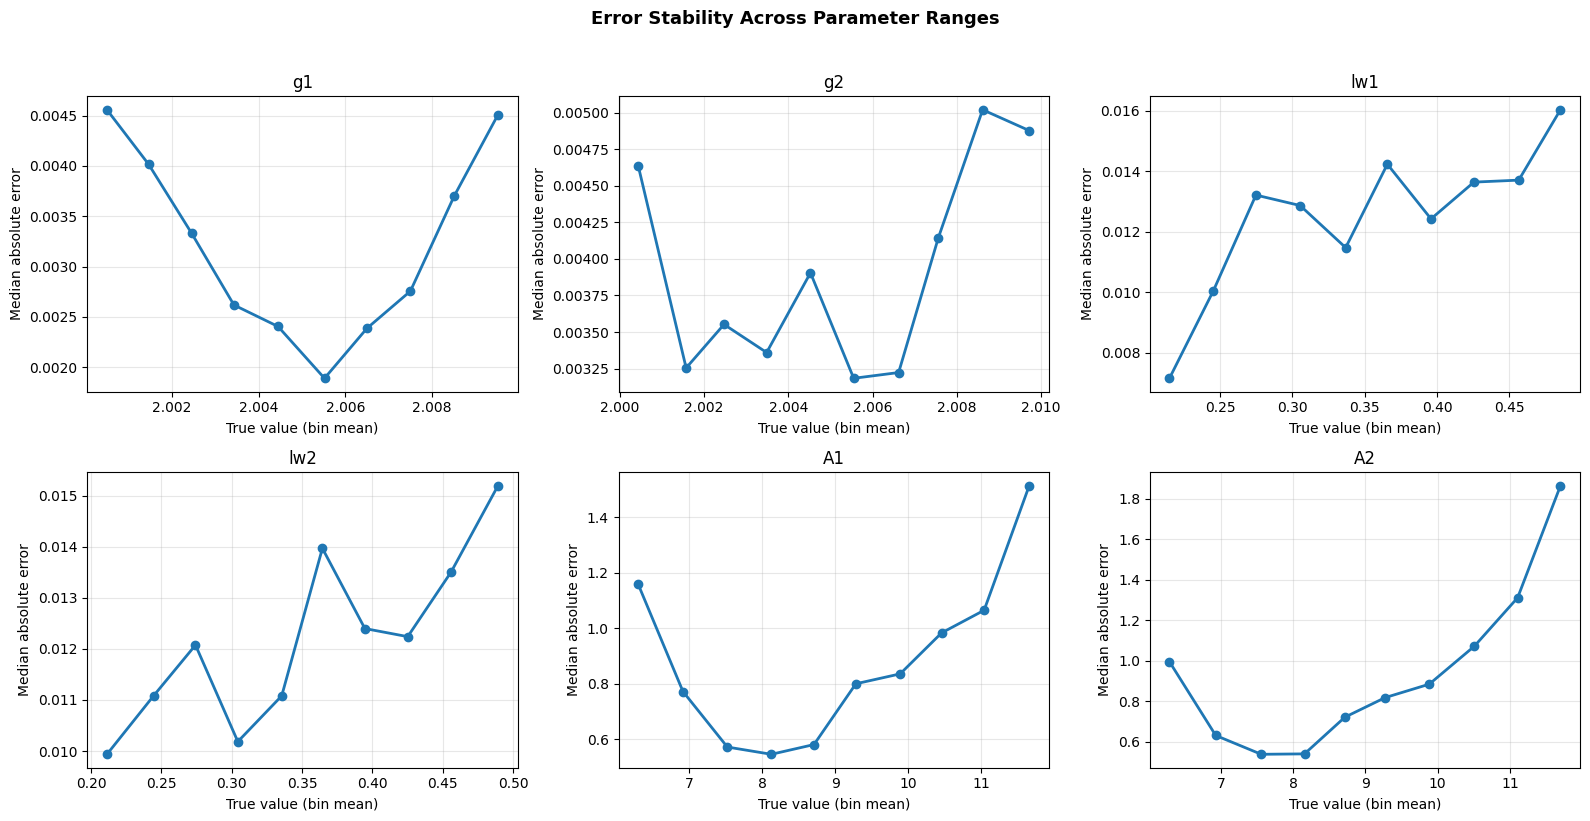

Poster-ready speed metrics
Single-sample latency: 104.22 ms
Batch(128) latency:    113.82 ms
Throughput:            1124.6 samples/s


In [69]:
import time

# Additional poster-ready analyses: practical accuracy, error trend, and speed

# Use existing parameter names
param_names = names if "names" in globals() else [f"p{i+1}" for i in range(y_true.shape[1])]
abs_err = np.abs(pred - y_true)

# -------------------- 1) Practical accuracy: % within tolerance --------------------
# Tunable tolerances (domain-friendly)
tol = np.array([0.005, 0.005, 0.02, 0.02, 1.0, 1.0])  # [g1,g2,lw1,lw2,A1,A2]
acc_within_tol = 100 * (abs_err <= tol).mean(axis=0)

plt.figure(figsize=(10, 4))
bars = plt.bar(param_names, acc_within_tol, color="#4C78A8")
plt.ylim(0, 100)
plt.ylabel("Samples within tolerance (%)")
plt.title("Practical Accuracy by Parameter")
plt.grid(axis="y", alpha=0.3)

for b, v in zip(bars, acc_within_tol):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# -------------------- 2) Error trend across value range (deciles) --------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for j, ax in enumerate(axes):
    t = y_true[:, j]
    e = abs_err[:, j]

    q_edges = np.quantile(t, np.linspace(0, 1, 11))
    bins = np.digitize(t, q_edges[1:-1], right=True)

    x_bin = np.array([t[bins == b].mean() for b in range(10) if np.any(bins == b)])
    y_bin = np.array([np.median(e[bins == b]) for b in range(10) if np.any(bins == b)])

    ax.plot(x_bin, y_bin, "o-", lw=2)
    ax.set_title(param_names[j])
    ax.set_xlabel("True value (bin mean)")
    ax.set_ylabel("Median absolute error")
    ax.grid(alpha=0.3)

plt.suptitle("Error Stability Across Parameter Ranges", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# -------------------- 3) Inference speed (single sample and batch) --------------------
n_runs = 30
sample = X_test[:1]
batch = X_test[:128]

# Warm-up
_ = model.predict(sample, verbose=0)
_ = model.predict(batch, verbose=0)

t0 = time.perf_counter()
for _ in range(n_runs):
    _ = model.predict(sample, verbose=0)
single_ms = (time.perf_counter() - t0) * 1000 / n_runs

t0 = time.perf_counter()
for _ in range(n_runs):
    _ = model.predict(batch, verbose=0)
batch_ms = (time.perf_counter() - t0) * 1000 / n_runs
throughput = 128 / (batch_ms / 1000)

print("Poster-ready speed metrics")
print(f"Single-sample latency: {single_ms:.2f} ms")
print(f"Batch(128) latency:    {batch_ms:.2f} ms")
print(f"Throughput:            {throughput:.1f} samples/s")

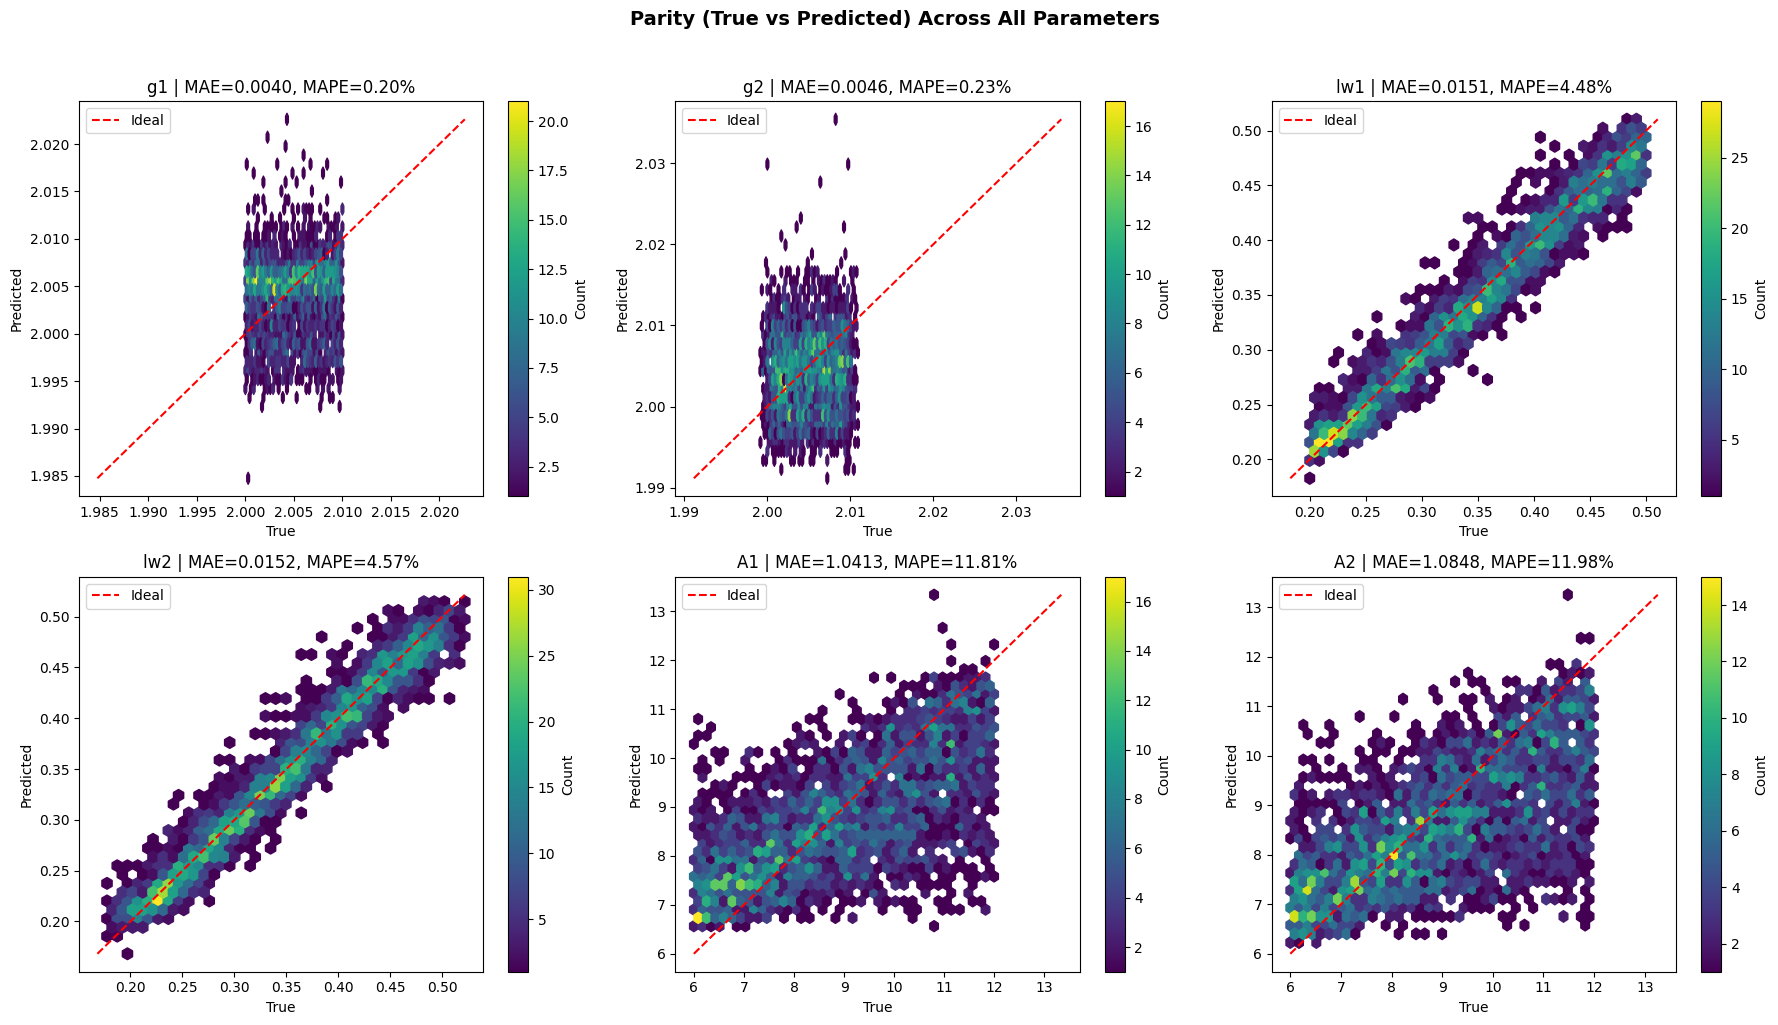

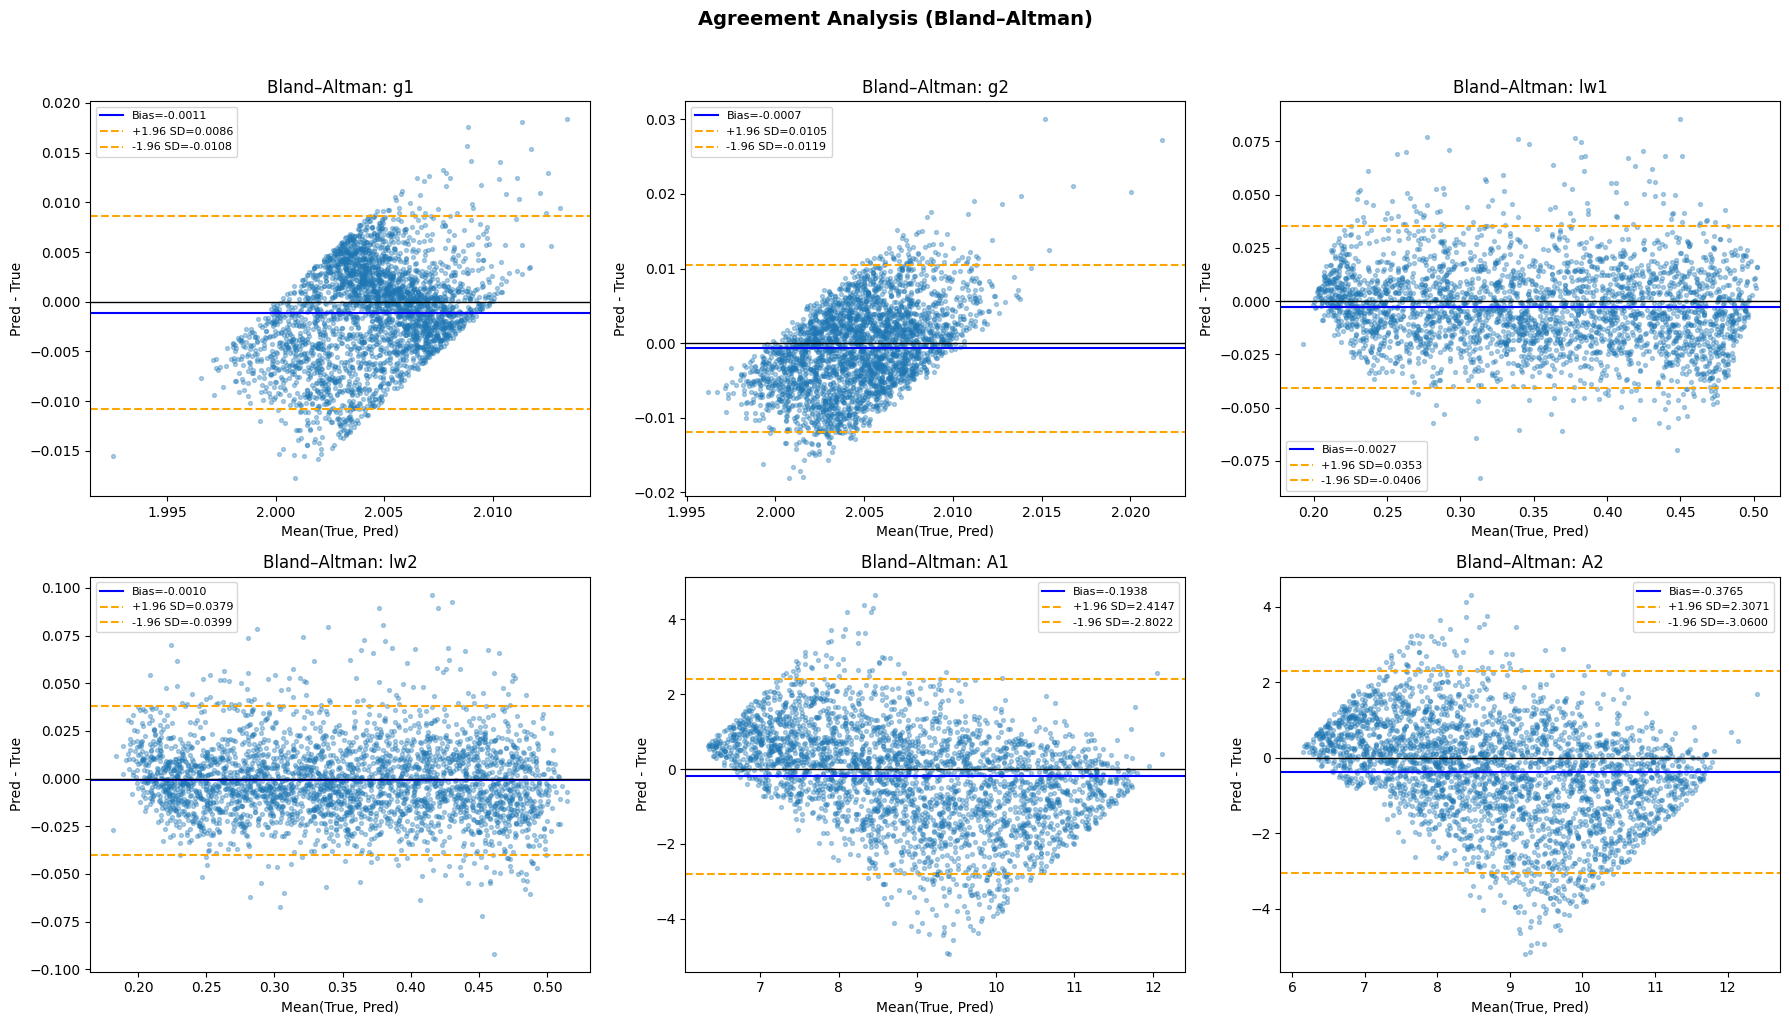

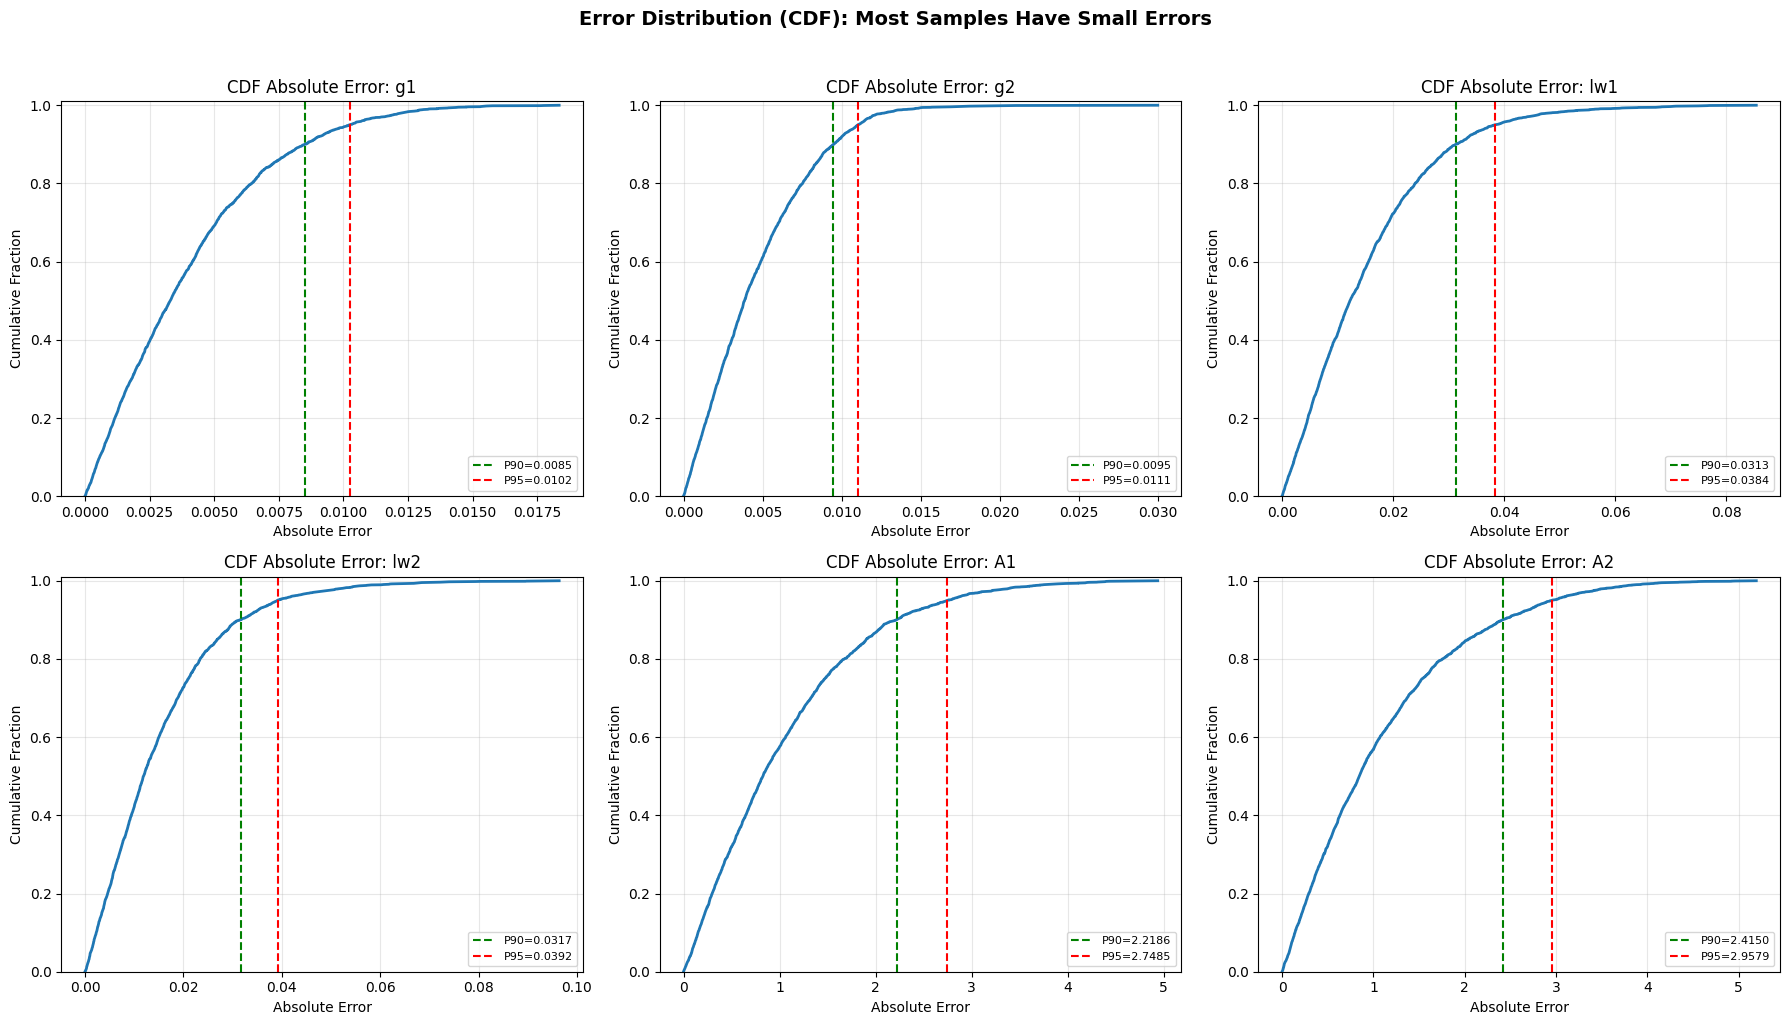

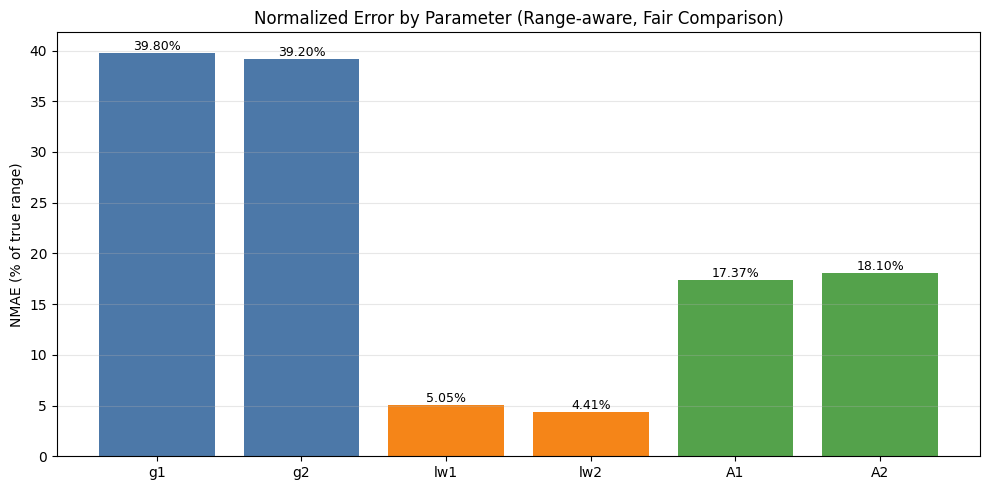

In [47]:
# Descriptive, publication-style evaluation plots (without hiding errors)

abs_err = np.abs(pred - y_true)
rel_err_pct = 100 * abs_err / (np.abs(y_true) + 1e-8)

# ---------- 1) Parity plots (True vs Pred) with density ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for j, ax in enumerate(axes):
	hb = ax.hexbin(
		y_true[:, j], pred[:, j],
		gridsize=35, cmap="viridis", mincnt=1
	)
	mn = min(y_true[:, j].min(), pred[:, j].min())
	mx = max(y_true[:, j].max(), pred[:, j].max())
	ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Ideal")

	mae_j = np.mean(abs_err[:, j])
	mape_j = np.mean(rel_err_pct[:, j])

	ax.set_title(f"{names[j]} | MAE={mae_j:.4f}, MAPE={mape_j:.2f}%")
	ax.set_xlabel("True")
	ax.set_ylabel("Predicted")
	ax.legend(loc="best")
	cb = fig.colorbar(hb, ax=ax)
	cb.set_label("Count")

plt.suptitle("Parity (True vs Predicted) Across All Parameters", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------- 2) Bland–Altman plots (agreement + bias visualization) ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for j, ax in enumerate(axes):
	mean_val = 0.5 * (y_true[:, j] + pred[:, j])
	diff_val = pred[:, j] - y_true[:, j]

	bias = np.mean(diff_val)
	sd = np.std(diff_val)
	loa_up = bias + 1.96 * sd
	loa_dn = bias - 1.96 * sd

	ax.scatter(mean_val, diff_val, s=8, alpha=0.35)
	ax.axhline(bias, color="blue", linestyle="-", label=f"Bias={bias:.4f}")
	ax.axhline(loa_up, color="orange", linestyle="--", label=f"+1.96 SD={loa_up:.4f}")
	ax.axhline(loa_dn, color="orange", linestyle="--", label=f"-1.96 SD={loa_dn:.4f}")
	ax.axhline(0, color="black", lw=1)

	ax.set_title(f"Bland–Altman: {names[j]}")
	ax.set_xlabel("Mean(True, Pred)")
	ax.set_ylabel("Pred - True")
	ax.legend(loc="best", fontsize=8)

plt.suptitle("Agreement Analysis (Bland–Altman)", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------- 3) CDF of absolute error (easy to show practical reliability) ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for j, ax in enumerate(axes):
	e = np.sort(abs_err[:, j])
	cdf = np.arange(1, len(e) + 1) / len(e)
	p90 = np.percentile(abs_err[:, j], 90)
	p95 = np.percentile(abs_err[:, j], 95)

	ax.plot(e, cdf, lw=2)
	ax.axvline(p90, color="green", linestyle="--", label=f"P90={p90:.4f}")
	ax.axvline(p95, color="red", linestyle="--", label=f"P95={p95:.4f}")
	ax.set_title(f"CDF Absolute Error: {names[j]}")
	ax.set_xlabel("Absolute Error")
	ax.set_ylabel("Cumulative Fraction")
	ax.set_ylim(0, 1.01)
	ax.grid(alpha=0.3)
	ax.legend(loc="lower right", fontsize=8)

plt.suptitle("Error Distribution (CDF): Most Samples Have Small Errors", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------- 4) Normalized MAE bar chart (fair cross-parameter comparison) ----------
true_range = np.ptp(y_true, axis=0) + 1e-8
mae_per_param = np.mean(abs_err, axis=0)
nmae_pct = 100 * mae_per_param / true_range  # relative to each parameter dynamic range

plt.figure(figsize=(10, 5))
bars = plt.bar(names, nmae_pct, color=["#4C78A8", "#4C78A8", "#F58518", "#F58518", "#54A24B", "#54A24B"])
plt.ylabel("NMAE (% of true range)")
plt.title("Normalized Error by Parameter (Range-aware, Fair Comparison)")
plt.grid(axis="y", alpha=0.3)

for b, v in zip(bars, nmae_pct):
	plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

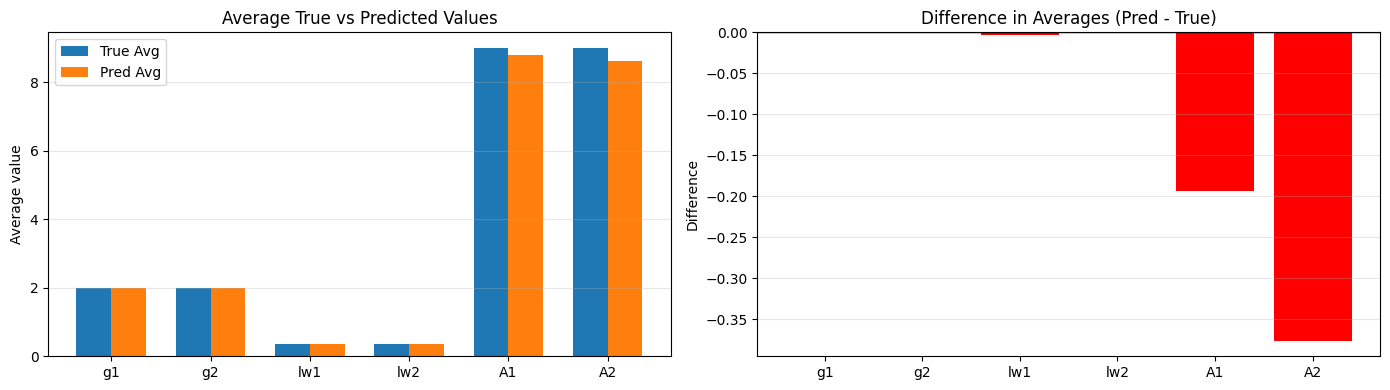

Average True: [2.00498524 2.00505635 0.35059021 0.34994252 8.99129543 9.01230829]
Average Pred: [2.0038874  2.0043743  0.3479344  0.34896216 8.797537   8.635848  ]
Difference (Pred - True): [-0.00109783 -0.00068208 -0.00265581 -0.00098036 -0.19375858 -0.37646025]


In [43]:
# Average values per output column
avg_true = y_true.mean(axis=0)
avg_pred = pred.mean(axis=0)
avg_diff = avg_pred - avg_true  # predicted - true

x = np.arange(len(names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1) True vs Predicted averages (separate bars)
axes[0].bar(x - w/2, avg_true, width=w, label="True Avg")
axes[0].bar(x + w/2, avg_pred, width=w, label="Pred Avg")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_title("Average True vs Predicted Values")
axes[0].set_ylabel("Average value")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# 2) Difference in averages
colors = ["green" if d >= 0 else "red" for d in avg_diff]
axes[1].bar(names, avg_diff, color=colors)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Difference in Averages (Pred - True)")
axes[1].set_ylabel("Difference")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: print values
print("Average True:", avg_true)
print("Average Pred:", avg_pred)
print("Difference (Pred - True):", avg_diff)

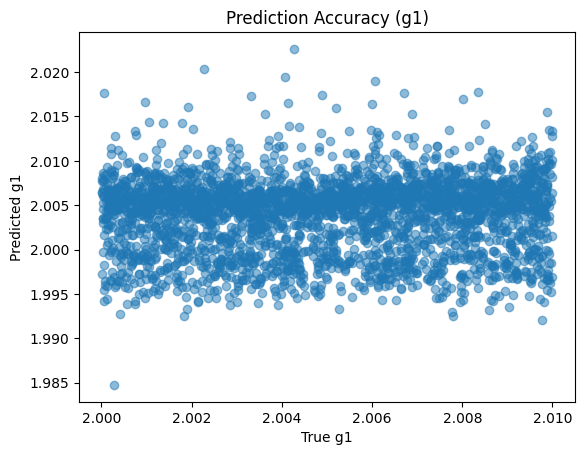

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_true[:,0], pred[:,0], alpha=0.5)
plt.xlabel("True g1")
plt.ylabel("Predicted g1")
plt.title("Prediction Accuracy (g1)")
plt.show()

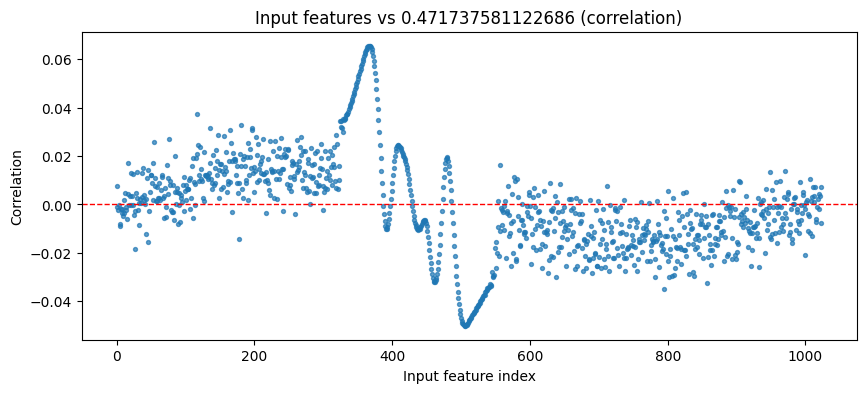

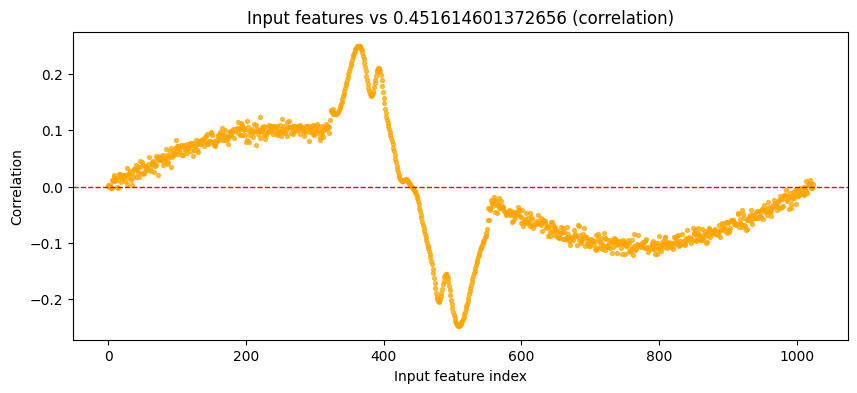

In [41]:
# Input features: all columns except last 6 target columns
X_df = df.iloc[:, :-6]
y_last2 = df.iloc[:, -4:]  # last 2 columns

feature_idx = np.arange(X_df.shape[1])

# Correlation of each input feature with the 2 last target columns
corr_last1 = X_df.corrwith(y_last2.iloc[:, 3])
corr_last2 = X_df.corrwith(y_last2.iloc[:, 1])

# Scatter plot for second-last column
plt.figure(figsize=(10, 4))
plt.scatter(feature_idx, corr_last1.values, s=8, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Input feature index")
plt.ylabel("Correlation")
plt.title(f"Input features vs {y_last2.columns[0]} (correlation)")
plt.show()

# Scatter plot for last column
plt.figure(figsize=(10, 4))
plt.scatter(feature_idx, corr_last2.values, s=8, alpha=0.7, color='orange')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Input feature index")
plt.ylabel("Correlation")
plt.title(f"Input features vs {y_last2.columns[1]} (correlation)")
plt.show()